# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

### B) Verificação dos dados faltantes

Foi realizada a verificação de valores ausentes utilizando o método `isnull().sum()`. Não foram encontrados dados faltantes em nenhuma das colunas da base.

Como não existem valores ausentes, não foi necessário realizar substituição ou remoção de registros.

In [3]:
print('Dimensões:', df.shape)
print('\nColunas:')
print(df.columns.tolist())

print('\nTipos das colunas:')
print(df.dtypes)

print('\nValores nulos:')
print(df.isnull().sum())


Dimensões: (7203, 7)

Colunas:
['Valor_Aluguel', 'Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']

Tipos das colunas:
Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

Valores nulos:
Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64


# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

Usei o .T porque prefiro essa visualização.

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Valor_Aluguel,7203.0,2966.596140,2948.720385,480.0,1350.0,2000.0,3200.0,25000.0
Valor_Condominio,7203.0,811.538109,796.564846,0.0,395.0,592.0,980.0,9500.0
Metragem,7203.0,88.506178,61.567505,30.0,52.0,67.0,100.0,880.0
N_Quartos,7203.0,2.300153,0.826615,1.0,2.0,2.0,3.0,10.0
N_banheiros,7203.0,2.095932,0.983812,1.0,2.0,2.0,2.0,8.0
N_Suites,7203.0,1.016660,0.874204,0.0,1.0,1.0,1.0,5.0
N_Vagas,7203.0,1.441760,0.869930,0.0,1.0,1.0,2.0,9.0


## B

In [5]:
Q1 = df['Valor_Aluguel'].quantile(0.25)
Q3 = df['Valor_Aluguel'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Limite inferior:', limite_inferior)
print('Limite superior:', limite_superior)

Q1: 1350.0
Q3: 3200.0
IQR: 1850.0
Limite inferior: -1425.0
Limite superior: 5975.0


In [6]:
outliers_aluguel = df[
    (df['Valor_Aluguel'] < limite_inferior) |
    (df['Valor_Aluguel'] > limite_superior)
]

print('Quantidade de possíveis outliers:', len(outliers_aluguel))

display(
    outliers_aluguel
    .sort_values(by='Valor_Aluguel', ascending=False)
    .head(20)
)
percentual_outliers = (
    len(outliers_aluguel) / len(df)
) * 100

print(f'Percentual de possíveis outliers: {percentual_outliers:.2f}%')

Quantidade de possíveis outliers: 749


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7202,25000,1587,248,4,3,2,4
7201,25000,6000,600,4,5,4,8
7200,25000,3700,266,3,4,3,7
7199,25000,4600,364,4,2,1,0
7198,25000,7500,627,4,5,4,6
7197,25000,5636,327,4,3,2,3
7196,25000,3320,222,4,5,4,9
7195,25000,1600,209,3,4,3,3
7194,25000,4500,306,3,4,3,5
7193,24000,4710,364,4,6,4,5


Percentual de possíveis outliers: 10.40%


### Insight

Após aplicar o método do intervalo interquartil, identifiquei 749 possíveis outliers na variável `Valor_Aluguel`, representando 10,40% da base. Esses valores correspondem aos aluguéis acima de R$ 5.975,00.

Decidi não remover esses registros porque eles podem representar imóveis reais com características diferenciadas, como maior metragem, mais quartos, mais banheiros ou melhor localização. Além disso, eles representam uma parte significativa da base, e sua remoção poderia eliminar informações importantes para o modelo.

## Outliers em N_Quartos
### Explicação
Vamos calcular o IQR para verificar quais valores de N_Quartos estão muito afastados da maior parte dos imóveis.

In [7]:
Q1_quartos = df['N_Quartos'].quantile(0.25)
Q3_quartos = df['N_Quartos'].quantile(0.75)

IQR_quartos = Q3_quartos - Q1_quartos

limite_inferior_quartos = Q1_quartos - 1.5 * IQR_quartos
limite_superior_quartos = Q3_quartos + 1.5 * IQR_quartos

print('Q1:', Q1_quartos)
print('Q3:', Q3_quartos)
print('IQR:', IQR_quartos)
print('Limite inferior:', limite_inferior_quartos)
print('Limite superior:', limite_superior_quartos)

Q1: 2.0
Q3: 3.0
IQR: 1.0
Limite inferior: 0.5
Limite superior: 4.5


In [8]:
outliers_quartos = df[
    (df['N_Quartos'] < limite_inferior_quartos) |
    (df['N_Quartos'] > limite_superior_quartos)
]

print(
    'Quantidade de possíveis outliers em N_Quartos:',
    len(outliers_quartos)
)

display(
    outliers_quartos
    .sort_values(by='N_Quartos', ascending=False)
    .head(20)
)

Quantidade de possíveis outliers em N_Quartos: 16


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6766,8000,0,273,10,4,1,8
6841,8700,5040,852,7,6,5,6
6786,8000,4200,510,6,5,4,3
7082,14000,5800,400,6,8,2,2
5830,4000,800,200,5,1,4,2
6243,5000,2688,380,5,3,2,5
6250,5000,1411,148,5,4,3,3
6531,6000,0,313,5,8,4,4
6597,6500,1550,234,5,5,4,3
6608,6500,1550,234,5,5,4,3


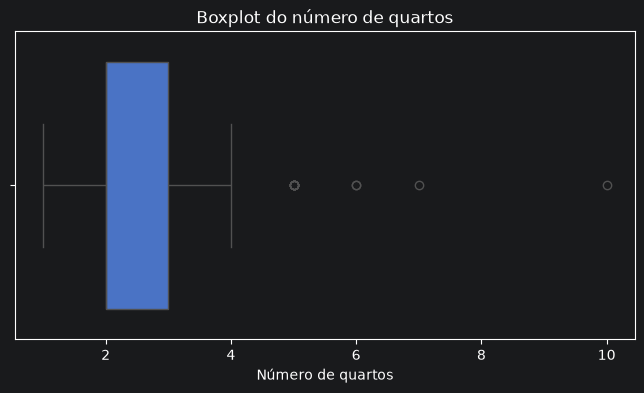

In [9]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df['N_Quartos']
)

plt.title('Boxplot do número de quartos')
plt.xlabel('Número de quartos')
plt.show()

In [10]:
print(df['N_Quartos'].value_counts().sort_index())

N_Quartos
1     1145
2     3265
3     2304
4      473
5       12
6        2
7        1
10       1
Name: count, dtype: int64


In [11]:

print('Linhas antes:', len(df))

# Remover imóveis com 6 quartos ou mais
df = df[df['N_Quartos'] < 6].reset_index(drop=True)

print('Linhas depois:', len(df))

# Conferir se ainda existem imóveis com 6 quartos ou mais
print('Registros com 6 quartos ou mais:')
print(df[df['N_Quartos'] >= 6])

Linhas antes: 7203
Linhas depois: 7199
Registros com 6 quartos ou mais:
Empty DataFrame
Columns: [Valor_Aluguel, Valor_Condominio, Metragem, N_Quartos, N_banheiros, N_Suites, N_Vagas]
Index: []


### Insight

A variável `N_Quartos` apresentou alguns valores muito acima do padrão da base. Foram identificados 16 possíveis outliers pelo método do IQR, mas a maior parte deles correspondia a imóveis com 5 quartos.

Após analisar a frequência dos valores, decidiu-se remover apenas os registros com 6 quartos ou mais. Esses valores eram pouco frequentes e foram considerados casos extremos para o conjunto analisado.

Foram removidos 4 registros: dois imóveis com 6 quartos, um com 7 quartos e um com 10 quartos. Os imóveis com 5 quartos foram mantidos, pois ainda podem representar uma categoria válida de imóvel.

## Outliers em N_banheiros
### Explicação
Vamos utilizar o método do intervalo interquartil, conhecido como IQR, para identificar valores muito afastados da distribuição principal.

In [12]:
Q1_banheiros = df['N_banheiros'].quantile(0.25)
Q3_banheiros = df['N_banheiros'].quantile(0.75)

IQR_banheiros = Q3_banheiros - Q1_banheiros

limite_inferior_banheiros = (
    Q1_banheiros - 1.5 * IQR_banheiros
)

limite_superior_banheiros = (
    Q3_banheiros + 1.5 * IQR_banheiros
)

print('Q1:', Q1_banheiros)
print('Q3:', Q3_banheiros)
print('IQR:', IQR_banheiros)
print('Limite inferior:', limite_inferior_banheiros)
print('Limite superior:', limite_superior_banheiros)

Q1: 2.0
Q3: 2.0
IQR: 0.0
Limite inferior: 2.0
Limite superior: 2.0


In [13]:
outliers_banheiros = df[
    (df['N_banheiros'] < limite_inferior_banheiros) |
    (df['N_banheiros'] > limite_superior_banheiros)
]

print(
    'Quantidade de possíveis outliers em N_banheiros:',
    len(outliers_banheiros)
)

display(
    outliers_banheiros
    .sort_values(by='N_banheiros', ascending=False)
    .head(20)
)

Quantidade de possíveis outliers em N_banheiros: 2933


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6531,6000,0,313,5,8,4,4
5825,4000,1123,160,3,7,3,3
6031,4500,3300,250,4,7,4,4
7124,16000,2800,370,5,7,4,5
5721,3700,1700,165,3,6,3,2
5459,3400,1378,180,4,6,3,2
7163,20000,2800,250,4,6,4,4
5210,3000,1600,250,4,6,3,3
7160,19000,2100,222,4,6,4,4
7063,14000,5000,290,4,6,4,4


In [14]:
print(
    df['N_banheiros']
    .value_counts()
    .sort_index()
)

N_banheiros
1    1676
2    4266
3     487
4     491
5     238
6      37
7       3
8       1
Name: count, dtype: int64


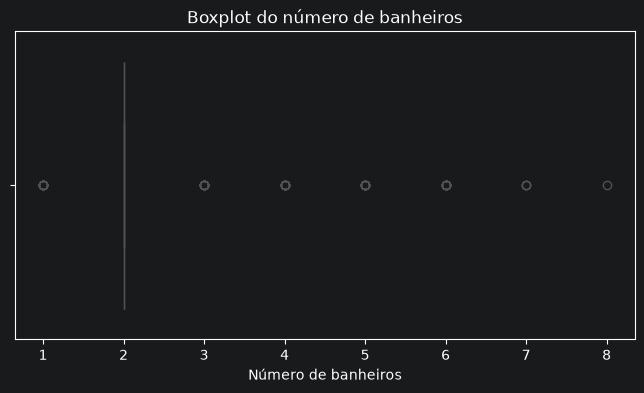

In [15]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df['N_banheiros']
)

plt.title('Boxplot do número de banheiros')
plt.xlabel('Número de banheiros')
plt.show()

### Tratamento dos outliers em `N_banheiros`

Na análise da variável `N_banheiros`, o primeiro e o terceiro quartis apresentaram o valor 2. Dessa forma, o IQR foi igual a zero, fazendo com que todos os valores diferentes de 2 fossem classificados como possíveis outliers.

Porém, essa classificação não significa que todos esses registros sejam inválidos. Os valores entre 1 e 6 banheiros aparecem com frequência na base e podem representar características reais dos imóveis.

Os valores de 7 e 8 banheiros foram considerados casos extremos, pois aparecem poucas vezes: existem apenas 3 imóveis com 7 banheiros e 1 imóvel com 8 banheiros. Por esse motivo, esses 4 registros foram removidos da base.

In [16]:
# Remover imóveis com 7 ou mais banheiros
df = df[df['N_banheiros'] < 7].reset_index(drop=True)

print('Nova dimensão da base:', df.shape)
print('Maior número de banheiros:', df['N_banheiros'].max())

Nova dimensão da base: (7195, 7)
Maior número de banheiros: 6


## Outliers em Valor_Condominio
### Explicação

Será realizada a análise de possíveis outliers na variável `Valor_Condominio` utilizando o método do intervalo interquartil, conhecido como IQR.

Esse método utiliza o primeiro quartil, o terceiro quartil e a diferença entre eles para calcular os limites inferior e superior da distribuição. Os valores acima do limite superior serão considerados possíveis outliers.


In [17]:
Q1_condominio = df['Valor_Condominio'].quantile(0.25)
Q3_condominio = df['Valor_Condominio'].quantile(0.75)

IQR_condominio = Q3_condominio - Q1_condominio

limite_inferior_condominio = (
    Q1_condominio - 1.5 * IQR_condominio
)

limite_superior_condominio = (
    Q3_condominio + 1.5 * IQR_condominio
)

print('Q1:', Q1_condominio)
print('Q3:', Q3_condominio)
print('IQR:', IQR_condominio)
print('Limite inferior:', limite_inferior_condominio)
print('Limite superior:', limite_superior_condominio)

Q1: 395.0
Q3: 980.0
IQR: 585.0
Limite inferior: -482.5
Limite superior: 1857.5


Quantidade de possíveis outliers em Valor_Condominio: 581


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6916,10000,9500,452,4,3,2,4
6805,8000,8860,414,4,5,4,4
7103,15000,8000,452,4,5,4,6
7112,15000,7928,340,3,4,3,5
7158,19900,7800,880,5,4,5,6
5096,3000,7500,393,4,6,4,6
7190,25000,7500,627,4,5,4,6
7102,15000,6800,456,4,5,4,5
4893,2800,6059,66,2,2,1,1
7193,25000,6000,600,4,5,4,8


Percentual de possíveis outliers: 8.08%


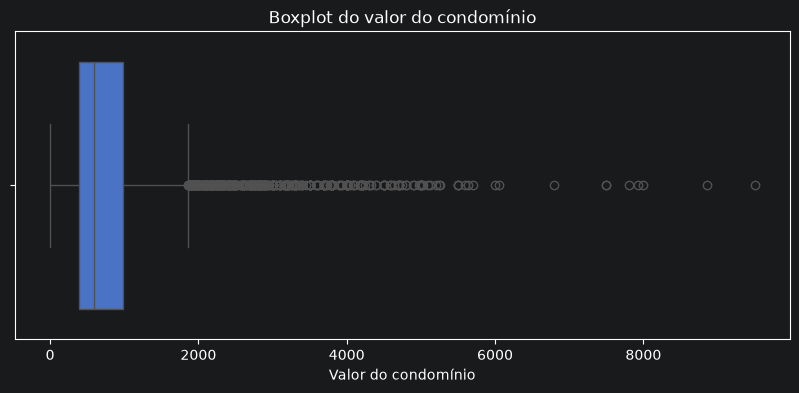

In [18]:
outliers_condominio = df[
    (df['Valor_Condominio'] < limite_inferior_condominio) |
    (df['Valor_Condominio'] > limite_superior_condominio)
]

print(
    'Quantidade de possíveis outliers em Valor_Condominio:',
    len(outliers_condominio)
)

display(
    outliers_condominio
    .sort_values(
        by='Valor_Condominio',
        ascending=False
    )
    .head(20)
)
percentual_outliers_condominio = (
    len(outliers_condominio) / len(df)
) * 100

print(
    f'Percentual de possíveis outliers: '
    f'{percentual_outliers_condominio:.2f}%'
)

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['Valor_Condominio']
)

plt.title('Boxplot do valor do condomínio')
plt.xlabel('Valor do condomínio')
plt.show()

In [19]:
display(
    outliers_condominio
    .sort_values(
        by='Valor_Condominio',
        ascending=False
    )
    .head(20)
)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6916,10000,9500,452,4,3,2,4
6805,8000,8860,414,4,5,4,4
7103,15000,8000,452,4,5,4,6
7112,15000,7928,340,3,4,3,5
7158,19900,7800,880,5,4,5,6
5096,3000,7500,393,4,6,4,6
7190,25000,7500,627,4,5,4,6
7102,15000,6800,456,4,5,4,5
4893,2800,6059,66,2,2,1,1
7193,25000,6000,600,4,5,4,8


In [20]:
df['Valor_Condominio'].describe()

count    7195.000000
mean      809.346213
std       791.245145
min         0.000000
25%       395.000000
50%       592.000000
75%       980.000000
max      9500.000000
Name: Valor_Condominio, dtype: float64

Vou confessar aqui que estou tendo bastante dificuldade devido à quantidade de possíveis outlines que estou encontrando.

### Explicação

Primeiro, vamos ordenar a base pelo `Valor_Condominio`, do maior para o menor.

Assim, conseguiremos observar quais imóveis possuem os maiores valores de condomínio e verificar suas outras características.

In [21]:
maiores_condominios = (
    df
    .sort_values(
        by='Valor_Condominio',
        ascending=False
    )
    .head(20)
)

display(maiores_condominios)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6916,10000,9500,452,4,3,2,4
6805,8000,8860,414,4,5,4,4
7103,15000,8000,452,4,5,4,6
7112,15000,7928,340,3,4,3,5
7158,19900,7800,880,5,4,5,6
7190,25000,7500,627,4,5,4,6
5096,3000,7500,393,4,6,4,6
7102,15000,6800,456,4,5,4,5
4893,2800,6059,66,2,2,1,1
7193,25000,6000,600,4,5,4,8


### Decisão sobre os outliers

Decidi não excluir os outliers de `Valor_Condominio`. Após realizar uma análise mais detalhada e refletir sobre os resultados, concluí que removê-los poderia ser um erro, principalmente porque esses registros representam uma quantidade significativa da base.

Além disso, os valores analisados parecem reais e compatíveis com as características dos imóveis. Por esse motivo, preferi mantê-los, mesmo sabendo que a presença desses valores pode influenciar o modelo e melhorar sua capacidade de prever imóveis com valores mais altos.

## N_Vagas
### Explicação

Será realizada a análise da variável `N_Vagas`, que representa a quantidade de vagas de garagem dos imóveis.

Como essa é uma variável inteira, vamos utilizar o método do intervalo interquartil, conhecido como IQR, para identificar valores muito afastados da distribuição principal. Depois, também vamos verificar a frequência de cada quantidade de vagas antes de decidir se algum registro deve ser removido.

In [22]:
Q1_vagas = df['N_Vagas'].quantile(0.25)
Q3_vagas = df['N_Vagas'].quantile(0.75)

IQR_vagas = Q3_vagas - Q1_vagas

limite_inferior_vagas = (
    Q1_vagas - 1.5 * IQR_vagas
)

limite_superior_vagas = (
    Q3_vagas + 1.5 * IQR_vagas
)

print('Q1:', Q1_vagas)
print('Q3:', Q3_vagas)
print('IQR:', IQR_vagas)
print('Limite inferior:', limite_inferior_vagas)
print('Limite superior:', limite_superior_vagas)
outliers_vagas = df[
    (df['N_Vagas'] < limite_inferior_vagas) |
    (df['N_Vagas'] > limite_superior_vagas)
]

print(
    'Quantidade de possíveis outliers em N_Vagas:',
    len(outliers_vagas)
)

display(
    outliers_vagas
    .sort_values(
        by='N_Vagas',
        ascending=False
    )
    .head(20)
)
print(
    df['N_Vagas']
    .value_counts()
    .sort_index()
)

Q1: 1.0
Q3: 2.0
IQR: 1.0
Limite inferior: -0.5
Limite superior: 3.5
Quantidade de possíveis outliers em N_Vagas: 250


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7188,25000,3320,222,4,5,4,9
7193,25000,6000,600,4,5,4,8
7123,16000,4800,425,5,6,5,7
7192,25000,3700,266,3,4,3,7
7077,14000,4981,306,3,4,3,6
6994,11700,5000,311,4,5,4,6
5096,3000,7500,393,4,6,4,6
7158,19900,7800,880,5,4,5,6
7103,15000,8000,452,4,5,4,6
6950,10000,4400,315,2,3,2,6


N_Vagas
0     294
1    4535
2    1601
3     515
4     200
5      39
6       7
7       2
8       1
9       1
Name: count, dtype: int64


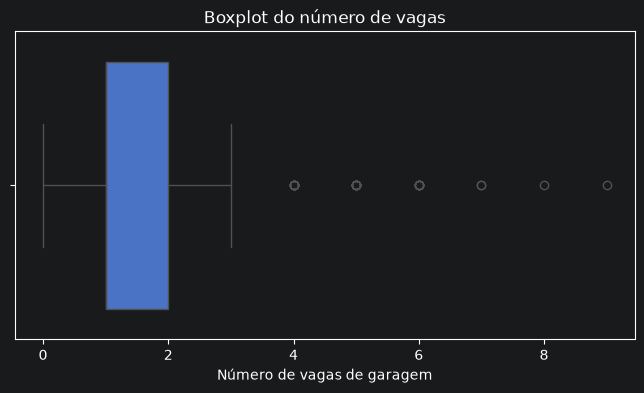

In [23]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df['N_Vagas']
)

plt.title('Boxplot do número de vagas')
plt.xlabel('Número de vagas de garagem')
plt.show()

In [24]:
percentual_outliers_vagas = (
    len(outliers_vagas) / len(df)
) * 100

print(
    f'Percentual de possíveis outliers: '
    f'{percentual_outliers_vagas:.2f}%'
)

Percentual de possíveis outliers: 3.47%


In [25]:
outliers_vagas = df[
    df['N_Vagas'] >= 4
]

display(
    outliers_vagas[
        [
            'Valor_Aluguel',
            'Valor_Condominio',
            'Metragem',
            'N_Quartos',
            'N_banheiros',
            'N_Suites',
            'N_Vagas'
        ]
    ]
    .sort_values(
        by='N_Vagas',
        ascending=False
    )
    .head(20)
)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7188,25000,3320,222,4,5,4,9
7193,25000,6000,600,4,5,4,8
7123,16000,4800,425,5,6,5,7
7192,25000,3700,266,3,4,3,7
7077,14000,4981,306,3,4,3,6
6994,11700,5000,311,4,5,4,6
5096,3000,7500,393,4,6,4,6
7158,19900,7800,880,5,4,5,6
7103,15000,8000,452,4,5,4,6
6950,10000,4400,315,2,3,2,6


### Tratamento dos outliers em `N_Vagas`

Após analisar a distribuição da variável `N_Vagas`, decidi remover os imóveis com 7 vagas ou mais.

Esses valores aparecem poucas vezes na base e representam casos extremos em relação à quantidade de vagas da maioria dos imóveis. Os valores entre 4 e 6 vagas foram mantidos, pois ainda podem representar imóveis maiores e com mais características.

Dessa forma, foram removidos apenas os registros com `N_Vagas >= 7`.

In [26]:
# Remover os registros com 7 vagas ou mais
df = df[df['N_Vagas'] < 7].reset_index(drop=True)

print('Nova dimensão da base:', df.shape)
print('Maior número de vagas:', df['N_Vagas'].max())

Nova dimensão da base: (7191, 7)
Maior número de vagas: 6


## Outliers em Metragem
### Explicação
Pelo resultado de describe(), a maior parte dos imóveis possui até 100 m², mas o maior imóvel tem 880 m². Isso indica que pode haver valores extremos.

In [27]:
Q1_metragem = df['Metragem'].quantile(0.25)
Q3_metragem = df['Metragem'].quantile(0.75)

IQR_metragem = Q3_metragem - Q1_metragem

limite_inferior_metragem = (
    Q1_metragem - 1.5 * IQR_metragem
)

limite_superior_metragem = (
    Q3_metragem + 1.5 * IQR_metragem
)

print('Q1:', Q1_metragem)
print('Q3:', Q3_metragem)
print('IQR:', IQR_metragem)
print('Limite inferior:', limite_inferior_metragem)
print('Limite superior:', limite_superior_metragem)

Q1: 52.0
Q3: 100.0
IQR: 48.0
Limite inferior: -20.0
Limite superior: 172.0


In [28]:
outliers_metragem = df[
    (df['Metragem'] < limite_inferior_metragem) |
    (df['Metragem'] > limite_superior_metragem)
]

print(
    'Quantidade de possíveis outliers em Metragem:',
    len(outliers_metragem)
)

display(
    outliers_metragem
    .sort_values(by='Metragem', ascending=False)
    .head(20)
)
percentual_outliers_metragem = (
    len(outliers_metragem) / len(df)
) * 100

print(
    f'Percentual de possíveis outliers: '
    f'{percentual_outliers_metragem:.2f}%'
)

Quantidade de possíveis outliers em Metragem: 636


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7157,19900,7800,880,5,4,5,6
7188,25000,7500,627,4,5,4,6
6856,9000,2280,574,4,1,4,5
7162,20000,4690,540,4,3,2,4
7163,20000,5030,540,4,3,2,4
6380,5500,2750,516,4,5,4,4
6847,9000,4583,510,5,5,4,3
7167,20000,4800,470,4,5,4,4
7164,20000,0,469,4,5,4,4
7165,20000,5705,469,4,5,4,4


Percentual de possíveis outliers: 8.84%


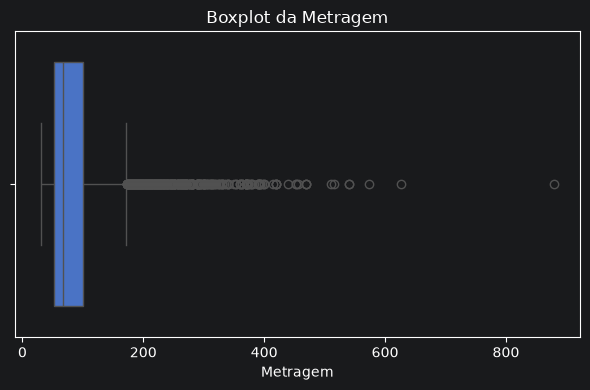

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Metragem")
plt.title("Boxplot da Metragem")
plt.xlabel("Metragem")
plt.tight_layout()
plt.show()

In [30]:
display(
    outliers_metragem
    .sort_values(
        by='Metragem',
        ascending=False
    )
    .head(20)
)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7157,19900,7800,880,5,4,5,6
7188,25000,7500,627,4,5,4,6
6856,9000,2280,574,4,1,4,5
7162,20000,4690,540,4,3,2,4
7163,20000,5030,540,4,3,2,4
6380,5500,2750,516,4,5,4,4
6847,9000,4583,510,5,5,4,3
7167,20000,4800,470,4,5,4,4
7164,20000,0,469,4,5,4,4
7165,20000,5705,469,4,5,4,4


In [31]:
df['Metragem'].value_counts().sort_index().tail(20)

Metragem
380    2
390    3
391    1
392    1
393    3
397    1
400    2
414    1
420    4
440    1
452    2
456    1
469    2
470    1
510    1
516    1
540    2
574    1
627    1
880    1
Name: count, dtype: int64

In [32]:
# Remover somente o registro com 880 m²
df = df[df['Metragem'] != 880].reset_index(drop=True)

print('Nova dimensão da base:', df.shape)
print('Maior metragem após o tratamento:', df['Metragem'].max())

Nova dimensão da base: (7190, 7)
Maior metragem após o tratamento: 627


### Tratamento do outlier em `Metragem`

Após analisar os possíveis outliers da variável `Metragem`, foi identificado um imóvel com 880 m². Esse valor aparece apenas uma vez e está muito acima dos demais registros da base.

Por esse motivo, o registro foi considerado um caso extremo para esta base e foi removido. Os demais imóveis com metragem superior a 172 m² foram mantidos, pois podem representar imóveis reais com áreas maiores.

# c

## 1. Valor do aluguel × metragem

### Explicação

Será utilizado um gráfico de dispersão para analisar a relação entre a metragem dos imóveis e o valor do aluguel.

Cada ponto representa um imóvel. A variável `Metragem` será colocada no eixo horizontal, enquanto `Valor_Aluguel` ficará no eixo vertical.

Esse gráfico permite verificar se imóveis maiores tendem a apresentar valores de aluguel mais altos.

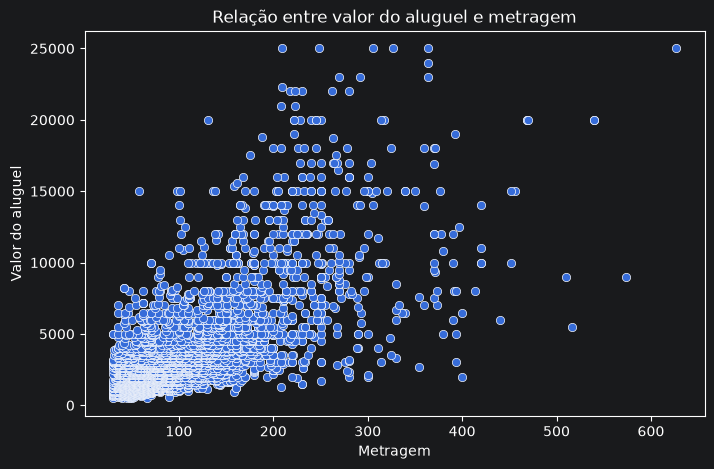

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Metragem',
    y='Valor_Aluguel'
)

plt.title('Relação entre valor do aluguel e metragem')
plt.xlabel('Metragem')
plt.ylabel('Valor do aluguel')
plt.show()

### Explicação

Inicialmente, seria analisada apenas a relação entre `Valor_Aluguel` e `Metragem`. Porém, esse gráfico apresentou poucas informações para uma análise mais completa, pois considerava somente duas características dos imóveis.

Por esse motivo, a análise foi ampliada com a inclusão das variáveis `N_Quartos` e `N_Suites`. Dessa forma, será possível observar o valor do aluguel considerando não apenas a metragem, mas também a quantidade de quartos e suítes de cada imóvel.

Essa ampliação permite obter uma visão mais completa dos fatores relacionados ao preço dos imóveis.

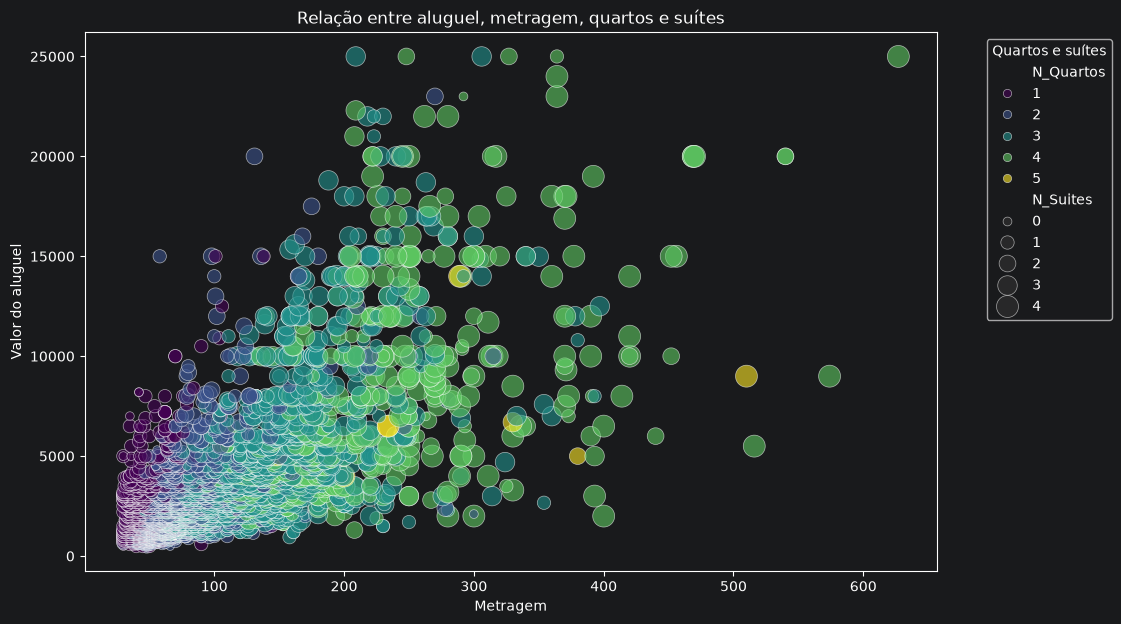

In [34]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x='Metragem',
    y='Valor_Aluguel',
    hue='N_Quartos',
    size='N_Suites',
    sizes=(40, 250),
    alpha=0.6,
    palette='viridis'
)

plt.title(
    'Relação entre aluguel, metragem, quartos e suítes'
)

plt.xlabel('Metragem')
plt.ylabel('Valor do aluguel')
plt.legend(
    title='Quartos e suítes',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

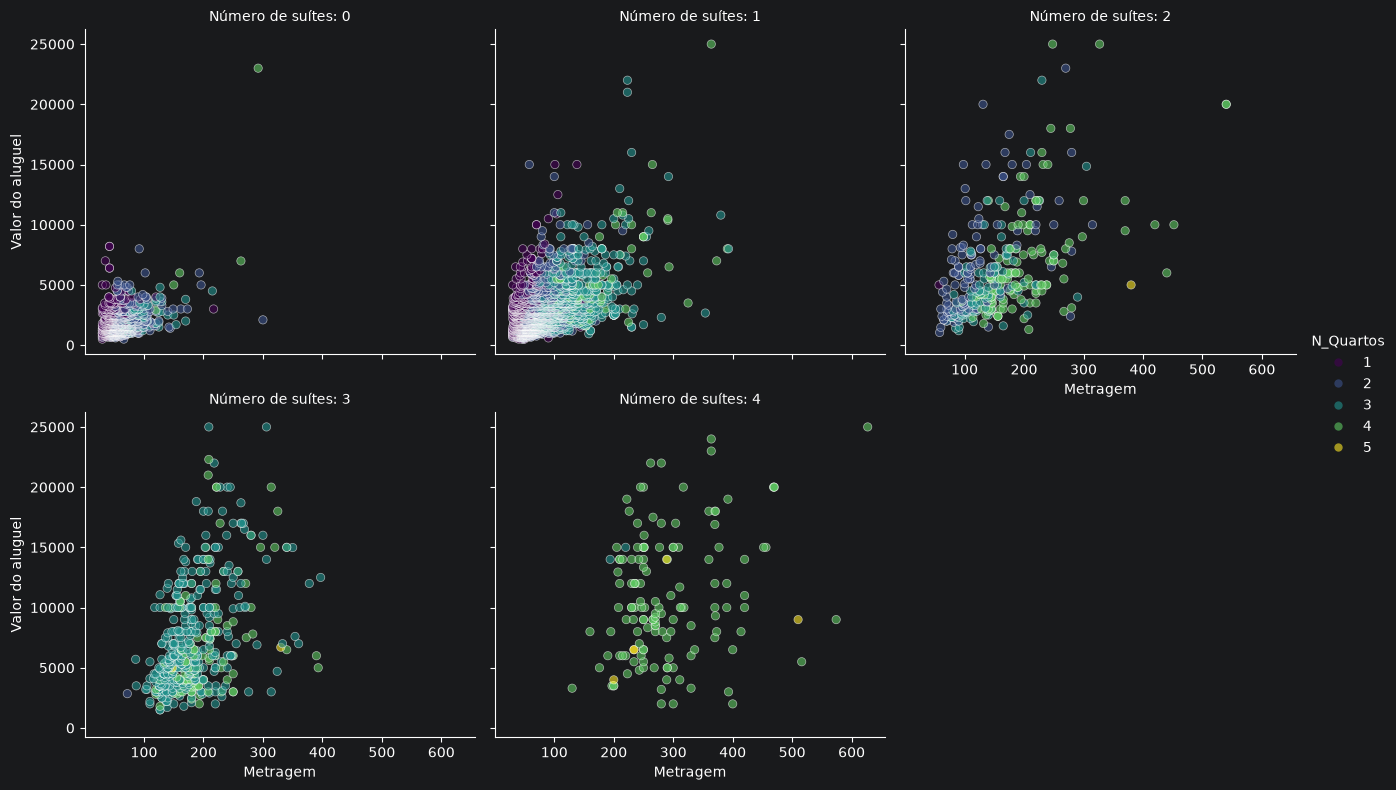

In [35]:
g = sns.relplot(
    data=df,
    x='Metragem',
    y='Valor_Aluguel',
    col='N_Suites',
    hue='N_Quartos',
    kind='scatter',
    col_wrap=3,
    height=4,
    aspect=1.1,
    alpha=0.6,
    palette='viridis'
)

g.set_axis_labels('Metragem', 'Valor do aluguel')
g.set_titles('Número de suítes: {col_name}')

plt.show()

### Insight

A análise mostra uma tendência geral de aumento no valor do aluguel conforme a metragem dos imóveis aumenta. Essa relação fica mais evidente nos imóveis com maior quantidade de suítes, principalmente nos grupos com 3 e 4 suítes.

Nos imóveis sem suítes, os valores de aluguel estão mais concentrados em imóveis menores e com preços mais baixos. Já nos grupos com 1, 2, 3 e 4 suítes, observa-se maior dispersão dos valores, incluindo imóveis com metragem e aluguel mais elevados.

As cores também indicam que os imóveis com maior número de quartos aparecem, em geral, associados a valores de aluguel mais altos. No entanto, existem pontos afastados do padrão, mostrando que metragem, quantidade de quartos e suítes não explicam sozinhas todas as diferenças nos valores dos aluguéis.

## Valor do aluguel × valor do condomínio
### Explicação

Será utilizado um gráfico de dispersão para analisar a relação entre o valor do condomínio e o valor do aluguel.

A variável `Valor_Condominio` será apresentada no eixo horizontal e `Valor_Aluguel` no eixo vertical. Cada ponto representa um imóvel.

O objetivo é verificar se imóveis com valores de condomínio maiores também tendem a apresentar valores de aluguel maiores. Também será possível observar a dispersão dos dados e a presença de valores muito afastados.

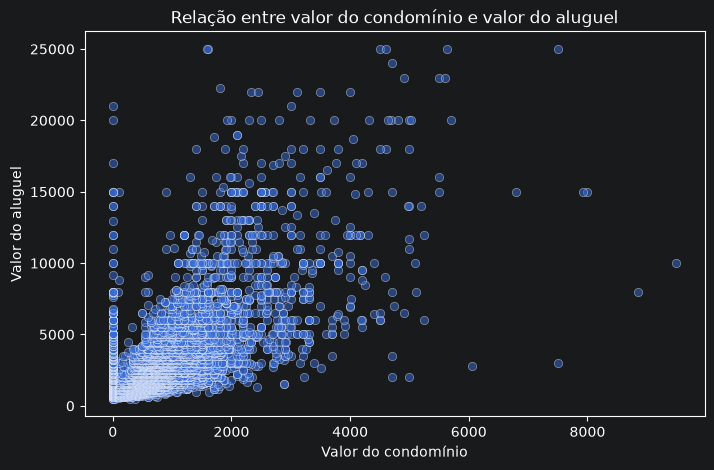

In [36]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Valor_Condominio',
    y='Valor_Aluguel',
    alpha=0.5
)

plt.title('Relação entre valor do condomínio e valor do aluguel')
plt.xlabel('Valor do condomínio')
plt.ylabel('Valor do aluguel')
plt.show()

### Insight

O gráfico mostra imóveis com diferentes combinações de valores de aluguel e condomínio, indicando que não existe apenas um padrão de preferência entre os moradores.

Algumas pessoas podem preferir imóveis com condomínios mais completos, bem cuidados e com opções de lazer, mesmo que isso resulte em um valor total mais alto. Outras podem preferir condomínios mais simples, buscando economizar nessa despesa e priorizar um valor de aluguel menor.

Essa variedade mostra que o valor do condomínio pode estar relacionado às características e à estrutura oferecida pelo imóvel, mas não determina sozinho o valor do aluguel.

## Valor do aluguel × número de quartos
### Explicação

Será utilizado um boxplot para comparar a distribuição dos valores de aluguel entre imóveis com diferentes quantidades de quartos.

A variável `N_Quartos` será apresentada no eixo horizontal e `Valor_Aluguel` no eixo vertical. O gráfico permitirá comparar as medianas, a dispersão e os possíveis valores extremos de cada grupo.

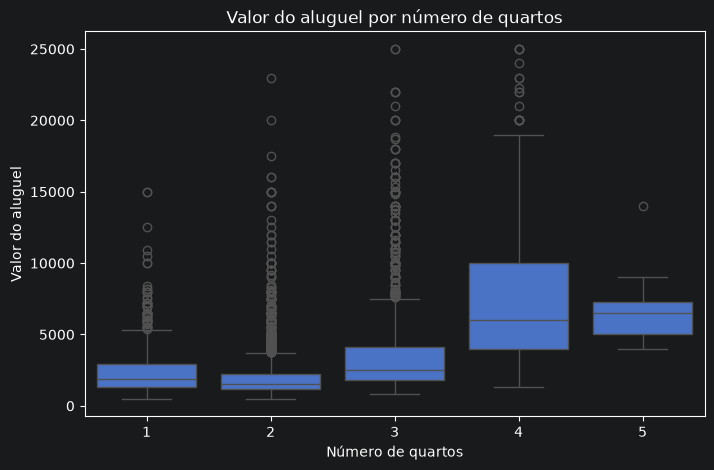

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='N_Quartos',
    y='Valor_Aluguel'
)

plt.title('Valor do aluguel por número de quartos')
plt.xlabel('Número de quartos')
plt.ylabel('Valor do aluguel')
plt.show()

### Insight

A análise entre `Valor_Aluguel` e `N_Quartos` mostra que os valores dos imóveis podem variar bastante mesmo entre aqueles que possuem a mesma quantidade de quartos.

Esse resultado reforça a importância de não remover automaticamente todos os possíveis outliers, pois a base pode conter imóveis de tamanhos e padrões diferentes. Além disso, a quantidade de quartos, sozinha, não é suficiente para explicar o valor do aluguel.

Com as variáveis disponíveis, não é possível tirar conclusões muito precisas sobre os preços. Por exemplo, imóveis localizados em regiões de campo ou em áreas maiores podem possuir mais quartos e características diferentes das residências comuns.

Também percebi que faltam informações importantes para explicar melhor o valor do aluguel, como a localização do imóvel e o valor médio do metro quadrado da região. Esses dados poderiam ajudar a entender melhor as diferenças de preço entre os imóveis.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




In [38]:
correlacao = df.corr(numeric_only=True)

display(correlacao.round(2))

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
Valor_Aluguel,1.00,0.69,0.73,0.41,0.60,0.61,0.64
Valor_Condominio,0.69,1.00,0.80,0.49,0.58,0.58,0.69
Metragem,0.73,0.80,1.00,0.68,0.69,0.70,0.74
N_Quartos,0.41,0.49,0.68,1.00,0.55,0.54,0.58
N_banheiros,0.60,0.58,0.69,0.55,1.00,0.92,0.70
N_Suites,0.61,0.58,0.70,0.54,0.92,1.00,0.71
N_Vagas,0.64,0.69,0.74,0.58,0.70,0.71,1.00


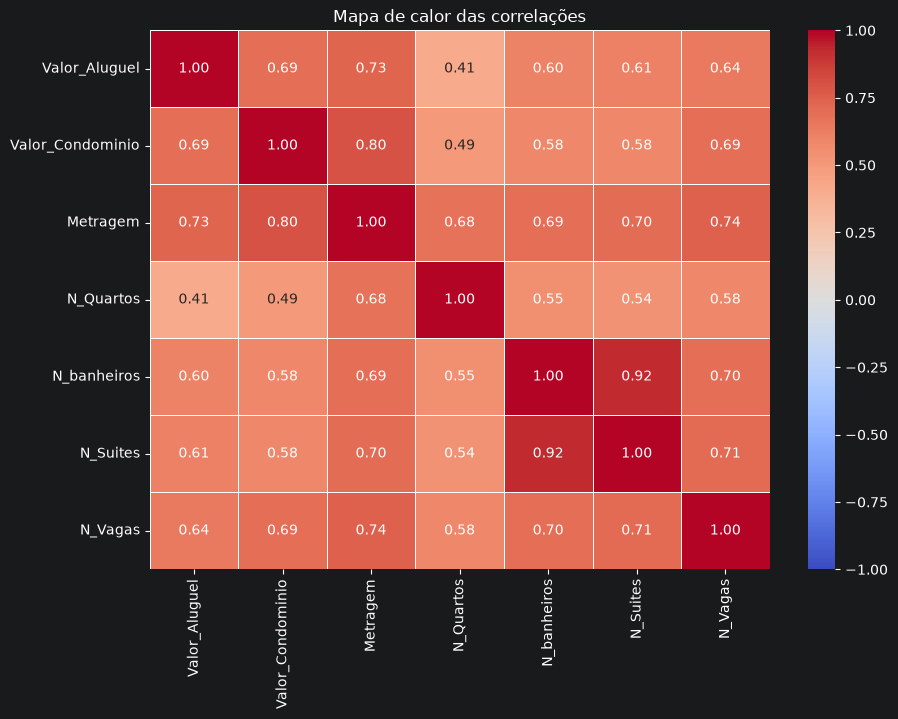

In [39]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title('Mapa de calor das correlações')
plt.show()

### Insight

A tabela mostra que a maioria das variáveis possui uma correlação positiva com `Valor_Aluguel`.

As maiores correlações foram:

- `Metragem`: 0,73;
- `Valor_Condominio`: 0,69;
- `N_Vagas`: 0,64.

Isso indica que imóveis maiores, com condomínios mais caros e mais vagas tendem a apresentar valores de aluguel maiores.

`N_Quartos` apresentou a menor correlação, com 0,41, mas ainda possui uma relação positiva com o valor do aluguel.


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [40]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [42]:
X = X_train[['Metragem']]  # Variável independente (características)
Y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [43]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
mod = LinearRegression()
mod.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[35.95]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Metragem']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-215.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [44]:

print("Intercepto:", mod.intercept_)
print("Coeficiente:", mod.coef_[0])

print(
    f"Equação da reta: Valor_Aluguel = "
    f"{mod.intercept_:.2f} + "
    f"({mod.coef_[0]:.2f} × Metragem)"
)

Intercepto: -215.20212705025915
Coeficiente: 35.95495135879504
Equação da reta: Valor_Aluguel = -215.20 + (35.95 × Metragem)


Nossa equação seria:  Equação da reta: Valor_Aluguel = -215.20 + (35.95 × Metragem)

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [45]:
r2_treino = mod.score(X,Y )

print(f"R² do treinamento: {r2_treino:.2f}")

R² do treinamento: 0.55


Com esse valor de \(R^2\), podemos concluir que o modelo explica aproximadamente **55% da variação do valor do aluguel**. O resultado é razoável, mas está longe de ser perfeito.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

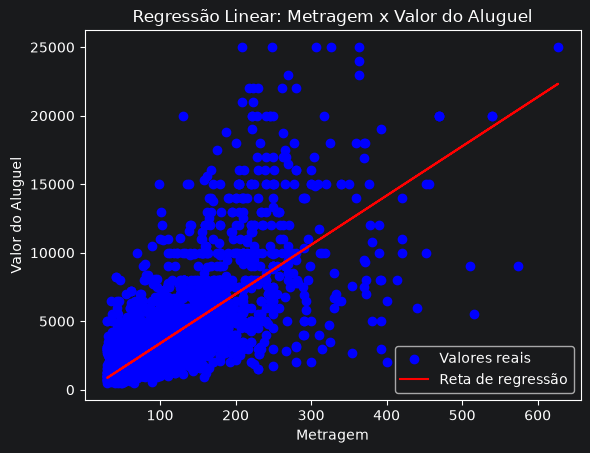

In [46]:
y_previsto = mod.predict(X)

plt.scatter( X,Y,
    color='blue',
    label='Valores reais'
)

plt.plot( X, y_previsto,
    color='red',
    label='Reta de regressão'
)

plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Linear: Metragem x Valor do Aluguel')
plt.legend()
plt.show()

Podemos observar que muitos pontos estão distantes da reta de regressão. Isso confirma o resultado do \(R^2 = 0,55\) e mostra que esse modelo não é o mais adequado para prever o valor do aluguel sozinho.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [47]:
Xx_test = X_test[['Metragem']]  # Variável independente (características)
yy_test = y_test  # Variável dependente (rótulo)

In [49]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = mod.predict(Xx_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = mod.score(Xx_test, yy_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.4950237640908054


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui. Podemos observar que o \(R^2\) foi de **0,55 no treino** e aproximadamente **0,50 no teste**, apresentando uma diferença de cerca de **5,5 pontos percentuais**. Lembrando o que a professora falou em aula, essa diferença não é muito grande. Portanto, considero que é uma diferença aceitável.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [50]:
X = X_train
Y = y_train

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [51]:
mod_m= LinearRegression()

mod_m.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.75, 24.17,-683.02, 246.91, 307.55, 398.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Valor_Condominio','Metragem','N_Quartos','N_banheiros','N_Suites', 'N_Vagas']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,385.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [52]:
r_multiplo = mod_m.score(X,Y )
print(r_multiplo)

0.6108312896431313


Podemos observar que, ao adicionar mais variáveis ao modelo, o \(R^2\) aumentou de **0,55 para 0,61**. Isso representa uma melhora importante, pois o modelo passou a explicar aproximadamente **61% da variação do valor do aluguel**.

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [53]:
X_testt = X_test
y_testt = y_test



In [55]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoesm = mod_m.predict(X_testt)

# Avaliando o desempenho do modelo usando métricas como o R²
r2m = mod_m.score(X_test, y_testt)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2m)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.579691359644018


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui  Ao comparar os modelos, podemos observar que a regressão linear simples apresentou \(R^2\) de **55%**, enquanto a regressão linear múltipla apresentou \(R^2\) de aproximadamente **61% no treino** e **58% no teste**.

Assim, a regressão múltipla parece ser melhor, pois apresentou um aumento de aproximadamente **6 pontos percentuais no treino** e **3 pontos percentuais no teste**. Isso provavelmente aconteceu porque ela utiliza mais variáveis que possuem correlação com o valor do aluguel, como metragem, valor do condomínio e número de vagas.